In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import SimpleITK as sitk
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from NoduleDS import NoduleDataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
BATCH_SIZE = 16
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01
MODEL_NAME = "resvit_3-4_42.pth"

# Paths - using pre-split data to avoid leakage
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"

train_images_path = os.path.join(split_base_path, "train", "images")
val_images_path = os.path.join(split_base_path, "val", "images")
test_images_path = os.path.join(split_base_path, "test", "images")

train_csv_path = os.path.join(split_base_path, "train", "metadata_train.csv")
val_csv_path = os.path.join(split_base_path, "val", "metadata_val.csv")
test_csv_path = os.path.join(split_base_path, "test", "metadata_test.csv")

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
# %% Load Pre-Split Data

# Also load original data for before/after comparison 
original_csv_path = "./nodule_dataset21/cxr_images/proccessed_data/metadata.csv"

print("Loading metadata...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# Try to load original data
try:
    original_df = pd.read_csv(original_csv_path)
    has_original = True
    print(f"Original dataset: {len(original_df)} samples")
except:
    has_original = False
    print("Original metadata not found, skipping before/after comparison")

print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

# Combine all splits for total distribution
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f"Total (combined): {len(combined_df)} samples")

Loading metadata...
Original metadata not found, skipping before/after comparison
Train: 5725 samples
Val: 782 samples
Test: 785 samples
Total (combined): 7292 samples


In [6]:
# Create datasets - each pointing to its own split directory
train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=False)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=False)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class TransformerBlock(nn.Module):
    """Ultra-lightweight Transformer block with spatial downsampling"""
    def __init__(self, dim, num_heads=2, mlp_ratio=1.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        B, C, H, W = x.shape
        
        # OPTIMIZATION: Downsample spatial dims for attention if too large
        if H * W > 196:  # If feature map > 14x14
            x_down = F.adaptive_avg_pool2d(x, (14, 14))
            B_d, C_d, H_d, W_d = x_down.shape
            x_seq = x_down.flatten(2).transpose(1, 2)
        else:
            x_seq = x.flatten(2).transpose(1, 2)
            H_d, W_d = H, W
        
        # Multi-head self-attention with residual
        x_norm = self.norm1(x_seq)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x_seq = x_seq + attn_out
        
        # MLP with residual
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        
        # Reshape back
        x_out = x_seq.transpose(1, 2).reshape(B, C, H_d, W_d)
        
        # Upsample back if needed
        if H_d != H or W_d != W:
            x_out = F.interpolate(x_out, size=(H, W), mode='bilinear', align_corners=False)
        
        return x + x_out  # Residual from original

class ResNetWithMultiScaleAttention(nn.Module):
    """ResNet-50 with lightweight transformer blocks at multiple scales"""
    def __init__(self, num_classes=2, pretrained=True, num_heads=2, dropout=0.1, active_stages=[1,2,3,4]):
        super().__init__()
        
        self.active_stages = active_stages
        
        # Load pretrained ResNet-50
        backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        
        # Extract ResNet stages
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.act1,
            backbone.maxpool
        )
        self.stage1 = backbone.layer1
        self.stage2 = backbone.layer2
        self.stage3 = backbone.layer3
        self.stage4 = backbone.layer4
        
        # Only initialize transformer blocks for active stages
        self.trans1 = TransformerBlock(256, num_heads=2, mlp_ratio=1.0, dropout=dropout) if 1 in active_stages else None
        self.trans2 = TransformerBlock(512, num_heads=2, mlp_ratio=1.0, dropout=dropout) if 2 in active_stages else None
        self.trans3 = TransformerBlock(1024, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout) if 3 in active_stages else None
        self.trans4 = TransformerBlock(2048, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout) if 4 in active_stages else None
        
        # Global average pooling and classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(2048, num_classes)
        
    def forward(self, x):
        x = self.stem(x)
        
        x = self.stage1(x)
        if self.trans1 is not None:
            x = self.trans1(x)
        
        x = self.stage2(x)
        if self.trans2 is not None:
            x = self.trans2(x)
        
        x = self.stage3(x)
        if self.trans3 is not None:
            x = self.trans3(x)
        
        x = self.stage4(x)
        if self.trans4 is not None:
            x = self.trans4(x)
        
        x = self.global_pool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        
        return x

In [8]:
# Initialize model
print("\nInitializing ResNet-50 with Multi-Scale Attention...")
model = ResNetWithMultiScaleAttention(num_classes=2, pretrained=False, num_heads=2, dropout=0.1, active_stages=[3,4])

# Load your trained ResNet-50 weights into the backbone
print("Loading pretrained ResNet-50 weights from ./resnet50_binary.pth...")
checkpoint = torch.load('./resnet50_binary.pth')

# Extract backbone weights from checkpoint
pretrained_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint

# Create a mapping for the backbone weights
model_dict = model.state_dict()
pretrained_dict_filtered = {}

for k, v in pretrained_dict.items():
    # Map old ResNet keys to new model structure
    if k.startswith('conv1'):
        pretrained_dict_filtered['stem.0.' + k] = v
    elif k.startswith('bn1'):
        pretrained_dict_filtered['stem.1.' + k] = v
    elif k.startswith('layer1'):
        pretrained_dict_filtered['stage1.' + k[7:]] = v
    elif k.startswith('layer2'):
        pretrained_dict_filtered['stage2.' + k[7:]] = v
    elif k.startswith('layer3'):
        pretrained_dict_filtered['stage3.' + k[7:]] = v
    elif k.startswith('layer4'):
        pretrained_dict_filtered['stage4.' + k[7:]] = v
    elif k.startswith('fc'):
        pretrained_dict_filtered['classifier.' + k[3:]] = v

# Update model dict with pretrained weights
model_dict.update(pretrained_dict_filtered)
model.load_state_dict(model_dict, strict=False)
print("✓ Loaded pretrained backbone weights")

model = model.to(device)

# FREEZE the entire backbone (only train transformer blocks + classifier)
for name, param in model.named_parameters():
    if 'trans' not in name and 'classifier' not in name:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total_params = trainable_params + frozen_params

print(f"\nParameter Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print(f"  Frozen parameters: {frozen_params:,} ({100*frozen_params/total_params:.2f}%)")

# Loss and optimizer (only optimize trainable params)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                       lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("\n✓ Model ready for training!")
print("✓ Frozen: ResNet backbone")
print("✓ Training: Transformer blocks + Classifier")


Initializing ResNet-50 with Multi-Scale Attention...
Loading pretrained ResNet-50 weights from ./resnet50_binary.pth...
✓ Loaded pretrained backbone weights

Parameter Summary:
  Total parameters: 55,000,130
  Trainable parameters: 31,492,098 (57.26%)
  Frozen parameters: 23,508,032 (42.74%)

✓ Model ready for training!
✓ Frozen: ResNet backbone
✓ Training: Transformer blocks + Classifier


In [9]:
# %% Training Functions
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        pbar.set_postfix({'loss': running_loss/len(loader), 'acc': 100.*correct/total})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # probability of positive class

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    # Binary metrics
    binary_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs, binary_precision, binary_recall, binary_f1, binary_auc

In [10]:
# Check for overlap
train_files = set(train_df['img_name'])
val_files = set(val_df['img_name'])
test_files = set(test_df['img_name'])

print(f"Train ∩ Val: {len(train_files & val_files)}")
print(f"Train ∩ Test: {len(train_files & test_files)}")
print(f"Val ∩ Test: {len(val_files & test_files)}")
# Should all be 0

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [11]:
# %% Training Loop
print("\nStarting training...")
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_precision': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_precision': []
}

best_val_f1 = 0.0
best_model_path = MODEL_NAME

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc, train_preds, train_labels, train_probs = train_epoch(
        model, train_loader, criterion, optimizer, device)
    
    # Calculate train metrics
    from sklearn.metrics import precision_score
    train_auc = roc_auc_score(train_labels, train_probs)
    train_precision = precision_score(train_labels, train_preds, average='binary', zero_division=0)
    
    # Validate - updated to unpack all 9 return values
    val_loss, val_acc, val_preds, val_labels, val_probs, val_precision, val_recall, val_f1, val_auc = validate(
        model, val_loader, criterion, device)
    
    # Step scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_precision'].append(train_precision)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_precision'].append(val_precision)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train AUC: {train_auc:.4f}, Train Precision: {train_precision:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f}, Val Precision: {val_precision:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_auc': val_auc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
        }, best_model_path)
        print(f"✓ Saved best model (Val F1: {val_f1:.2f}%, Val Recall: {val_recall:.2f}%)")

print("\nTraining completed!")


Starting training...

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:13<00:00,  3.76it/s]


Train Loss: 0.5976, Train Acc: 79.69%, Train AUC: 0.8672, Train Precision: 0.8122
Val Loss: 0.5165, Val Acc: 76.34%, Val AUC: 0.9217, Val Precision: 0.5538
LR: 0.000100
✓ Saved best model (Val F1: 0.69%, Val Recall: 0.92%)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:12<00:00,  3.83it/s]


Train Loss: 0.4028, Train Acc: 83.88%, Train AUC: 0.9175, Train Precision: 0.8442
Val Loss: 0.3515, Val Acc: 84.40%, Val AUC: 0.9029, Val Precision: 0.8012
LR: 0.000098
✓ Saved best model (Val F1: 0.69%, Val Recall: 0.61%)

Epoch 3/25
--------------------------------------------------


...

Train Loss: 0.1425, Train Acc: 94.13%, Train AUC: 0.9876, Train Precision: 0.9461
Val Loss: 0.2022, Val Acc: 92.71%, Val AUC: 0.9690, Val Precision: 0.8962
LR: 0.000002
✓ Saved best model (Val F1: 0.87%, Val Recall: 0.84%)

Epoch 24/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:13<00:00,  3.51it/s]


Train Loss: 0.1370, Train Acc: 94.50%, Train AUC: 0.9882, Train Precision: 0.9462
Val Loss: 0.2021, Val Acc: 92.84%, Val AUC: 0.9689, Val Precision: 0.8930
LR: 0.000000
✓ Saved best model (Val F1: 0.87%, Val Recall: 0.85%)

Epoch 25/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:14<00:00,  3.45it/s]

Train Loss: 0.1463, Train Acc: 94.52%, Train AUC: 0.9866, Train Precision: 0.9503
Val Loss: 0.2126, Val Acc: 91.56%, Val AUC: 0.9655, Val Precision: 0.8533
LR: 0.000000

Training completed!


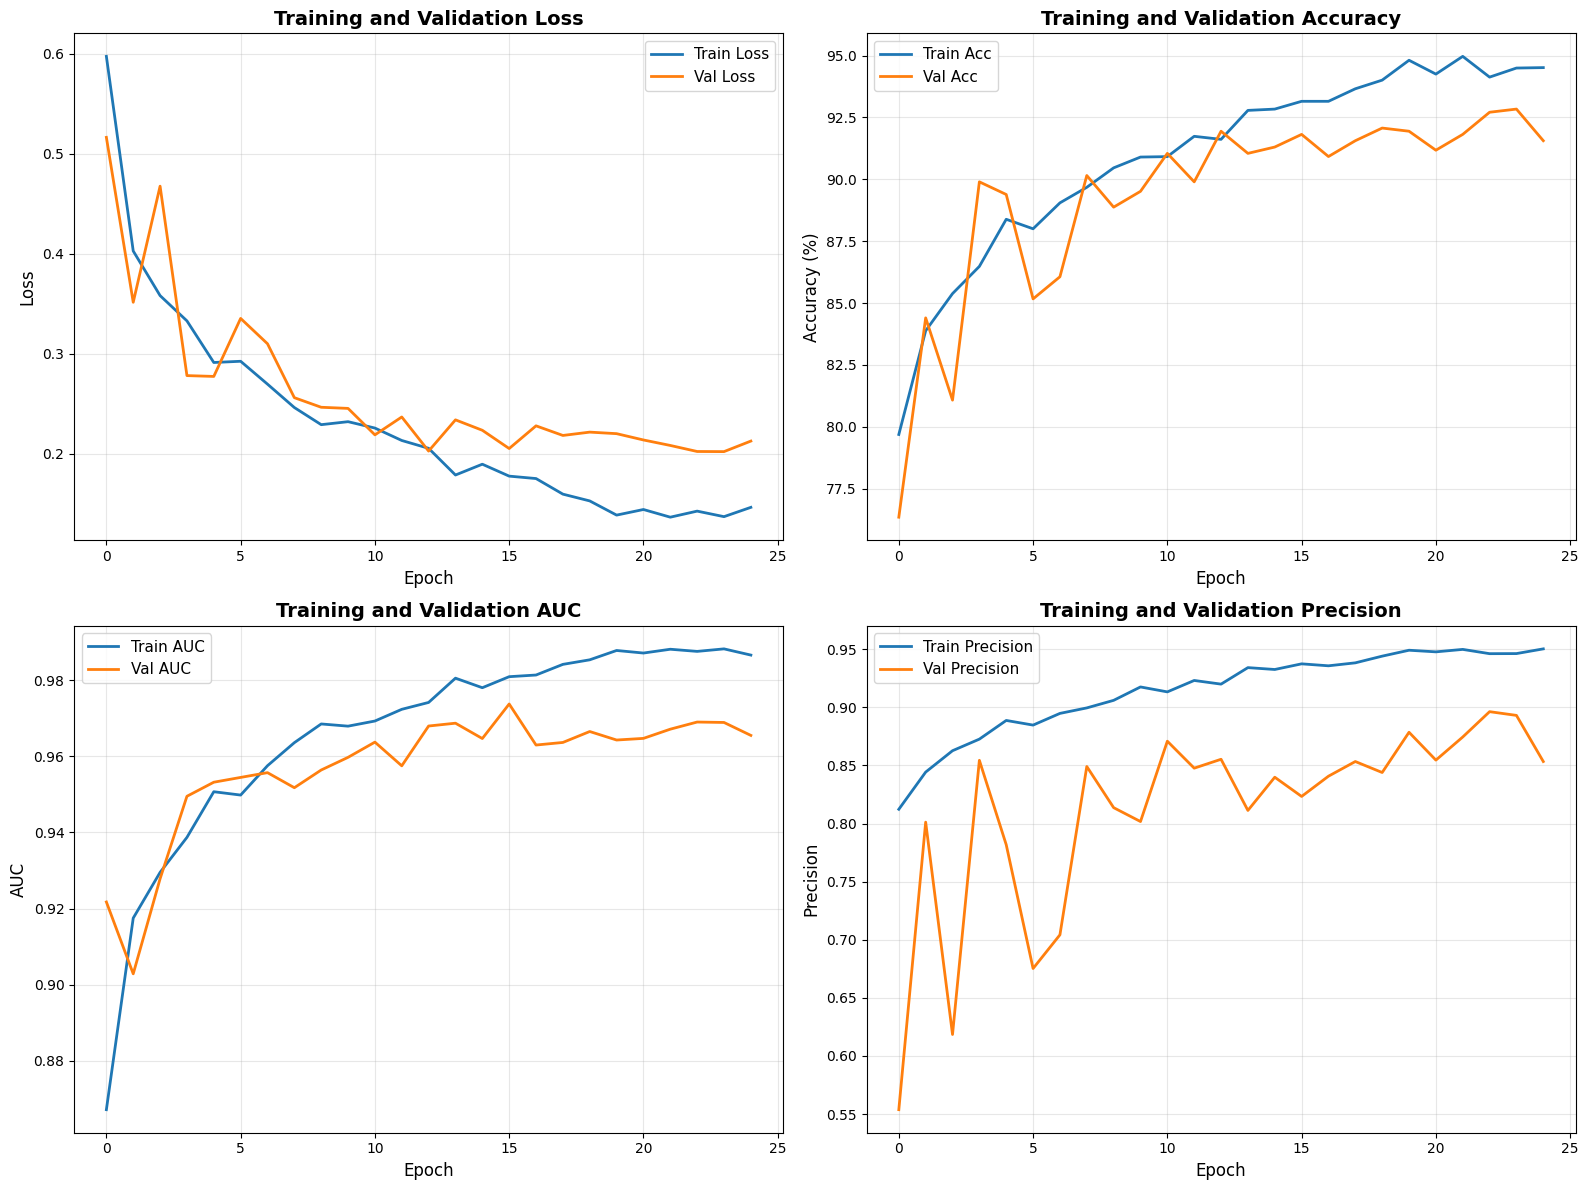

In [12]:
# %% Plot Training History
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# AUC plot
ax3.plot(history['train_auc'], label='Train AUC', linewidth=2)
ax3.plot(history['val_auc'], label='Val AUC', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('AUC', fontsize=12)
ax3.set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Precision plot
ax4.plot(history['train_precision'], label='Train Precision', linewidth=2)
ax4.plot(history['val_precision'], label='Val Precision', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Training and Validation Precision', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [13]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
checkpoint = torch.load("./" + MODEL_NAME)
model.load_state_dict(checkpoint['model_state_dict'])
    # Validate - updated to unpack all 9 return values
    
test_loss, test_acc, test_preds, test_labels, test_probs, test_precision, test_recall, test_f1, test_auc = validate(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule'], digits=4))

# ROC AUC Score
auc = roc_auc_score(test_labels, test_probs)
print(f"\nROC AUC Score: {auc:.4f}")


Loading best model for testing...


Validation: 100%|██████████| 50/50 [00:16<00:00,  3.11it/s]


Test Results:
Test Loss: 0.1609
Test Accuracy: 94.90%

Classification Report:
              precision    recall  f1-score   support

   No Nodule     0.9648    0.9648    0.9648       568
      Nodule     0.9078    0.9078    0.9078       217

    accuracy                         0.9490       785
   macro avg     0.9363    0.9363    0.9363       785
weighted avg     0.9490    0.9490    0.9490       785


ROC AUC Score: 0.9773


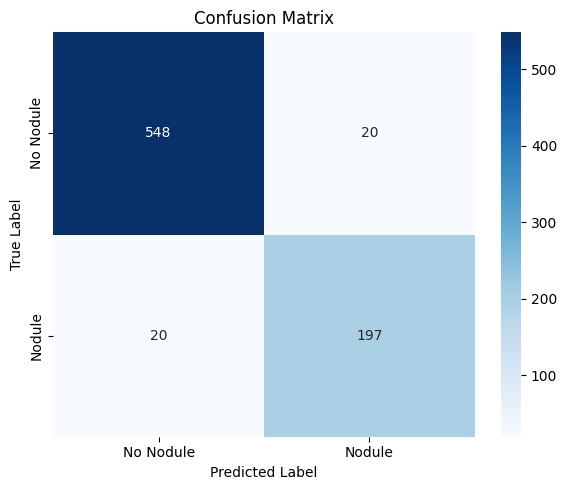

✓ Saved: confusion_matrix.png


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_labels = ['No Nodule', 'Nodule']

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
print("✓ Saved: confusion_matrix.png")


In [15]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
best_model_path = MODEL_NAME
model = ResNetWithMultiScaleAttention(num_classes=2, pretrained=False, num_heads=2, dropout=0.1, active_stages=[3,4])
model = model.to(device)
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_rec, test_f1, test_auc = validate(model, test_loader, criterion, device)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test ROC AUC: {test_auc:.4f}")

print(f"\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule']))


Loading best model for testing...


Validation: 100%|██████████| 50/50 [00:12<00:00,  3.86it/s]


Test Loss: 0.1609
Test Accuracy: 94.90%
Test Precision: 0.9078
Test Recall: 0.9078
Test F1-score: 0.9078
Test ROC AUC: 0.9773

TEST SET RESULTS
Test Loss: 0.1609
Test Accuracy: 94.90%

Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.96      0.96      0.96       568
      Nodule       0.91      0.91      0.91       217

    accuracy                           0.95       785
   macro avg       0.94      0.94      0.94       785
weighted avg       0.95      0.95      0.95       785



In [16]:
# %% Test on Subset Data
import os
import pandas as pd
from torch.utils.data import DataLoader
import numpy as np

print("\nTesting on subset data...")

# Load subset metadata
subset_csv_path = "./dataset_nodule21/cxr_images/proccessed_data/subset_metadata2.csv"
subset_images_path = "./dataset_nodule21/cxr_images/proccessed_data/images"

subset_df = pd.read_csv(subset_csv_path)
print(f"Subset dataset: {len(subset_df)} samples")
print(f"\nClass distribution:")
print(f"  Nodule (1): {(subset_df['label'] == 1).sum()}")

# Create subset dataset (no bbox needed for this model)
subset_dataset = NoduleDataset(subset_df, subset_images_path, transform=val_transform, return_bbox=False)
subset_loader = DataLoader(subset_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                           num_workers=NUM_WORKERS, pin_memory=True)

# Evaluate on subset
print("\nEvaluating model on subset...")
subset_loss, subset_acc, subset_preds, subset_labels, subset_probs, subset_prec, subset_rec, subset_f1, subset_auc = validate(
    model, subset_loader, criterion, device)

# Convert to numpy arrays if they aren't already
subset_preds = np.array(subset_preds)
subset_labels = np.array(subset_labels)

# Calculate False Positive Rate (FPR)
# For nodule detection: FP = predicted 0 when actual is 1
false_positives = np.sum((subset_preds == 0) & (subset_labels == 1))
total_positives = np.sum(subset_labels == 1)
false_positive_rate = (false_positives / total_positives * 100) if total_positives > 0 else 0

# Print results
print("\n" + "="*70)
print("SUBSET TEST RESULTS (NODULE-ONLY DATASET)")
print("="*70)
print(f"Subset Loss: {subset_loss:.4f}")
print(f"Subset Accuracy: {subset_acc:.2f}%")
print(f"Subset Precision: {subset_prec:.4f}")
print(f"Subset Recall (True Positive Rate): {subset_rec:.4f}")
print(f"Subset F1-score: {subset_f1:.4f}")
print(f"Subset ROC AUC: {subset_auc:.4f}")
print(f"\nFalse Positive Rate: {false_positive_rate:.2f}%")
print(f"   (Nodules incorrectly classified as No Nodule: {false_positives}/{total_positives})")

# Classification Report (only show Nodule class)
print("\nClassification Report:")
from sklearn.metrics import classification_report
print(classification_report(subset_labels, subset_preds, target_names=['No Nodule', 'Nodule'], labels=[1]))

# Visualization - Detection breakdown only
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Detection breakdown
labels_bar = ['True Positives\n(Correctly detected)', 'False Negatives\n(Missed nodules)']
true_positives = np.sum((subset_preds == 1) & (subset_labels == 1))
values = [true_positives, false_positives]
colors_bar = ["#574ea5", "#38ca70"]

bars = ax.barh(labels_bar, values, color=colors_bar, alpha=0.8, edgecolor='white', linewidth=2)
ax.set_xlabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Nodule Detection Results (Subset Data)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.set_xlim(0, 190)

# Add value labels on bars
for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, 
             f'{int(val)} ({val/total_positives*100:.1f}%)',
             va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix_subset.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved: confusion_matrix_subset.png")

# Compare with main test set
print("\n" + "="*70)
print("COMPARISON: TEST SET vs SUBSET (NODULE-ONLY)")
print("="*70)
print(f"{'Metric':<25} {'Test Set':<15} {'Subset':<15} {'Difference':<15}")
print("-" * 75)
print(f"{'Accuracy (%)':<25} {test_acc:<15.2f} {subset_acc:<15.2f} {subset_acc - test_acc:<+15.2f}")
print(f"{'F1-Score':<25} {test_f1:<15.4f} {subset_f1:<15.4f} {subset_f1 - test_f1:<+15.4f}")
print(f"{'ROC AUC':<25} {test_auc:<15.4f} {subset_auc:<15.4f} {subset_auc - test_auc:<+15.4f}")
print(f"{'False Positive Rate (%)':<25} {'N/A':<15} {false_positive_rate:<15.2f} {'N/A':<15}")
print("="*75)

print(f"\n💡 Note: False Positive Rate = % of nodules misclassified as 'No Nodule'")
print(f"   Higher FPR = Model is missing more nodules in this subset")


Testing on subset data...
Subset dataset: 171 samples

Class distribution:
  Nodule (1): 171

Evaluating model on subset...


Validation:   0%|          | 0/11 [00:04<?, ?it/s]


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\NoduleDS.py", line 28, in __getitem__
    image = sitk.ReadImage(img_path)
  File "c